In [56]:
%pip install ucimlrepo scikit-learn matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error # MAE 
from sklearn.metrics import mean_squared_error  # RMSE
from sklearn.metrics import r2_score            # R2 (coefficient of determination)

In [59]:
# Load the UCI dataset into a pandas DataFrame.
from ucimlrepo import fetch_ucirepo

real_estate = fetch_ucirepo(id=477)  # Downloads the UCI dataset whose repository ID is 477 and stores the resulting dataset object in the variable real_estate.

X = real_estate.data.features  # Extracts the predictor variables from the dataset and stores them in the pandas DataFrame X. These variables will eventually be used as inputs to our regression model.     
y = real_estate.data.targets   # Extracts the target variable from the dataset and stores it in y. In this experiment, the target is house price per unit area.

print(X.head())   # Displays the first five rows of the predictor DataFrame. This provides a quick way to verify that the data have been loaded correctly.
print(y.head())   # Displays the first five target values. This allows us to inspect the values that the regression model will eventually try to predict.

   X1 transaction date  X2 house age  X3 distance to the nearest MRT station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4 number of convenience stores  X5 latitude  X6 longitude  
0                               10     24.98298     121.54024  
1                                9     24.98034     121.53951  
2                                5     24.98746     121.54391  
3                                5     24.98746     121.54391  
4                                5     24.97937     121.54245  
   Y house price of unit area
0                        37.9
1                        42.2
2                        47.3
3              

In [60]:
# Then, combine them:
df = pd.concat([X, y], axis=1)  # pd.concat() combines the predictor DataFrame X and target DataFrame y. The argument axis=1 means that they are joined column-wise, producing one DataFrame containing all variables.

print(df.head())  # Displays the first five rows of the complete dataset. This lets us inspect the predictors and target together.

   X1 transaction date  X2 house age  X3 distance to the nearest MRT station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4 number of convenience stores  X5 latitude  X6 longitude  \
0                               10     24.98298     121.54024   
1                                9     24.98034     121.53951   
2                                5     24.98746     121.54391   
3                                5     24.98746     121.54391   
4                                5     24.97937     121.54245   

   Y house price of unit area  
0                        37.9  
1                        42.2  
2                        47.3  


In [61]:
# Use this for getting further details:

# Examine the dataset size
print(df.shape)   # The .shape attribute returns the number of rows and columns in the DataFrame. For this dataset, students should obtain 414 rows and 7 columns in the combined DataFrame.
print('\n')

# Examine the dataset structure
print(df.info())  # The .info() method displays the column names, number of non-null values, and data types. It is useful for checking the general structure of the dataset and identifying missing values.
print('\n')

# Check missing values
print(df.isnull().sum())   # isnull() identifies missing values, while .sum() counts the missing values in each column. This allows students to quickly determine whether preprocessing is required for missing data.

(414, 7)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
 6   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB
None


X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                   

In [62]:
# Extract 'X3 distance to the nearest MRT station' and 'Y house price of unit area' columns as two dataframes for scikit-learn
X_uni = df[['X3 distance to the nearest MRT station']]   # Selects the distance to the nearest MRT station column from the DataFrame and stores it in X_uni as a pandas DataFrame. The double brackets [[ ]] ensure that the result remains two-dimensional, which is the expected input format for scikit-learn.
y = df['Y house price of unit area']   # Selects the house price per unit area column and stores it in y as a pandas Series. This is the continuous target variable that the regression model will learn to predict.

print(X_uni.head())  # Displays the first five observations of the selected predictor. This confirms that the correct input variable has been selected.
print('\n')
print(y.head())   # Displays the first five target values. This allows us to verify that the correct output variable has been selected.

   X3 distance to the nearest MRT station
0                                84.87882
1                               306.59470
2                               561.98450
3                               561.98450
4                               390.56840


0    37.9
1    42.2
2    47.3
3    54.8
4    43.1
Name: Y house price of unit area, dtype: float64


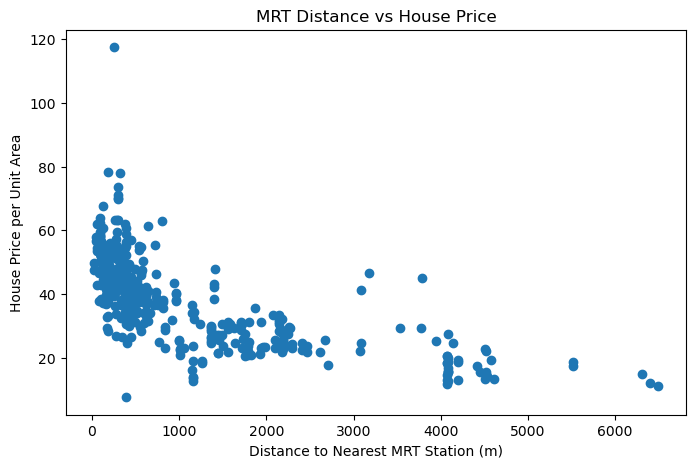

In [63]:
# Before fitting a regression model, we should examine whether a relationship appears to exist between MRT distance (X_uni) and house price (y).
plt.figure(figsize=(8, 5))   # Creates a new Matplotlib figure. figsize=(8, 5) specifies the width and height of the figure in inches.

# Creates a scatter plot in which MRT distance is placed on the x-axis and house price on the y-axis. Each point represents one property observation.
plt.scatter(
    X_uni['X3 distance to the nearest MRT station'],
    y
)

plt.xlabel('Distance to Nearest MRT Station (m)')   # Adds a descriptive label to the x-axis. The label indicates that MRT distance is measured in metres.
plt.ylabel('House Price per Unit Area')   # Adds a label to the y-axis identifying the target variable being predicted.
plt.title('MRT Distance vs House Price')  # Adds a descriptive title to the graph so that the purpose of the visualization is immediately clear. 

plt.show()   # Displays the completed Matplotlib figure in the notebook.

In [64]:
# Separate the data into training and testing sets (80% + 20%).

# Creates four variables: predictor training data (X_train), predictor testing data (X_test), target training data (y_train), and target testing data (y_test).
# Calls scikit-learn's function for randomly dividing data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_uni,   # Provides the univariate predictor data to be divided.
    y,       # Provides the corresponding target values.
    test_size=0.20,   # Specifies that 20% of the observations should be reserved for testing and approximately 80% for training.
    random_state=42   # Sets a fixed random seed so that the same observations are selected each time the notebook is executed.
)

print("Training samples:", len(X_train))   # len(X_train) counts the number of observations in the training dataset. The result helps verify that approximately 80% of the observations were used for training.
print("Training samples:", len(X_test))    # Counts the number of observations reserved for testing. Approximately 20% of the original observations should appear here.
print("Training samples:", len(y_train))
print("Training samples:", len(y_test))

Training samples: 331
Training samples: 83
Training samples: 331
Training samples: 83


In [65]:
# Create a linear regression model using scikit-learn.

# Creates an instance of scikit-learn's LinearRegression model and stores it in model_uni. At this stage, the model has been created but has not yet learned the regression coefficients.
model_uni = LinearRegression()  

# Trains the regression model using the training predictors and corresponding target values. The .fit() method estimates the intercept and coefficient that best fit the training data according to ordinary least squares.
model_uni.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [66]:
# Obtain the regression parameters:

# model_uni.intercept_ contains the estimated (b_0) value. It represents the model's predicted target when the predictor value is zero.
print("Intercept:", model_uni.intercept_)

# model_uni.coef_ contains the estimated regression coefficient(s). Since this model has only one predictor, [0] extracts its single coefficient.
print("Coefficient:", model_uni.coef_[0])

Intercept: 46.24269004533652
Coefficient: -0.007409512934932929


In [67]:
# Predict prices for the testing data.

# Uses the trained regression model to predict house prices for the observations in X_test. The resulting values are stored in y_pred.
y_pred = model_uni.predict(X_test)

# Displays the first ten predicted house prices. The [:10] slice selects the first ten values from the prediction array.
print(y_pred[:10])

[44.80832319 42.59549586 44.2123768  44.98211776 30.05195586 43.0970243
 44.0989342  44.0989342  37.74895049 45.5724547 ]


In [68]:
# Compare actual and predicted values

# Creates a new pandas DataFrame containing two columns: 
# 1. the actual house prices and 2. the corresponding predicted values. 
# y_test.values extracts the underlying values from the pandas Series.
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

# Displays the first ten rows of the comparison table so we can directly compare actual prices with model predictions.
print(comparison.head(10))

   Actual  Predicted
0    45.1  44.808323
1    42.3  42.595496
2    52.2  44.212377
3    37.3  44.982118
4    22.8  30.051956
5    36.3  43.097024
6    53.0  44.098934
7    51.4  44.098934
8    16.1  37.748950
9    59.0  45.572455


In [69]:
# mean_absolute_error() calculates the Mean Absolute Error (MAE) between the actual test values and predicted values. 
# MAE represents the average absolute prediction error in the same unit as the target.
mae = mean_absolute_error(y_test, y_pred)

# mean_squared_error() calculates the mean squared prediction error. 
# np.sqrt() takes its square root, producing Root Mean Squared Error (RMSE), which is expressed in the same unit as the target.
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

# r2_score() calculates the coefficient of determination, R². 
# It indicates how much of the variation in the test target is explained by the predictions relative to a mean-based baseline.
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 6.920972703573579
RMSE: 8.79454329599807
R²: 0.5389597665019771


C:\Users\hasan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


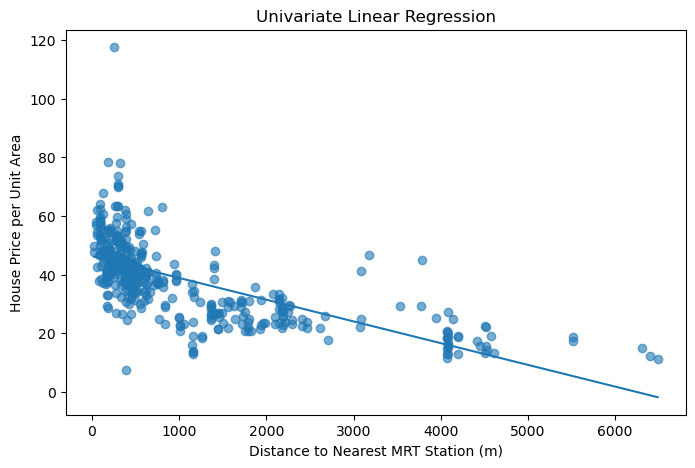

In [70]:
# Visualize the fitted linear relationship.
x_line = np.linspace(
    X_uni.min().iloc[0],   # Finds the minimum MRT distance in the dataset and extracts the numerical value.
    X_uni.max().iloc[0],   # Finds the maximum MRT distance in the dataset.
    100                    # Creates 100 evenly spaced MRT-distance values between the minimum and maximum. These values will be used to draw a smooth regression line.
).reshape(-1, 1)           # Converts the one-dimensional NumPy array into a two-dimensional array with one feature, matching the format expected by scikit-learn.

# Uses the trained model to calculate predicted house prices for the 100 MRT-distance values in x_line. 
# These predicted values form the regression line.
y_line = model_uni.predict(x_line)

# Creates a new figure with a width of 8 inches and height of 5 inches.
plt.figure(figsize=(8, 5))

# Plots all observed properties as scatter points. alpha=0.6 makes the points partially transparent so overlapping observations are easier to see.
plt.scatter(
    X_uni,
    y,
    alpha=0.6
)

# Draws the fitted regression line using the MRT-distance values and their corresponding predicted prices.
plt.plot(
    x_line,
    y_line
)

plt.xlabel('Distance to Nearest MRT Station (m)')   # Labels the x-axis with the predictor and its unit.
plt.ylabel('House Price per Unit Area')   # Labels the y-axis with the target variable.
plt.title('Univariate Linear Regression')   # Provides a title describing the model represented in the visualization.

plt.show()   # Displays the completed scatter plot and regression line.

In [71]:
# Create a Python list containing the names of the six predictor columns that will be used in the multiple regression model.
feature_columns = [
    'X1 transaction date',
    'X2 house age',
    'X3 distance to the nearest MRT station',
    'X4 number of convenience stores',
    'X5 latitude',
    'X6 longitude'
]

# Uses the list of column names to select all six predictors from the DataFrame. The selected variables are stored in X_multi.
X_multi = df[feature_columns]

# Selects the house-price column as the target variable. This is the value the multivariate model will learn to predict.
y = df['Y house price of unit area']

# Displays the first five rows of the selected predictor variables. This verifies that the intended features have been selected.
print(X_multi.head())
# Displays the dimensions of the predictor DataFrame. Students should see 414 observations and six predictor columns.
print(X_multi.shape)
print('\n')

# # Displays the first five rows of the target variable.
print(y.head())
print(y.shape)

   X1 transaction date  X2 house age  X3 distance to the nearest MRT station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4 number of convenience stores  X5 latitude  X6 longitude  
0                               10     24.98298     121.54024  
1                                9     24.98034     121.53951  
2                                5     24.98746     121.54391  
3                                5     24.98746     121.54391  
4                                5     24.97937     121.54245  
(414, 6)


0    37.9
1    42.2
2    47.3
3    54.8
4    43.1
Name: Y house price of unit area, dtype: float64
(414,)


In [72]:
# The .describe() method calculates summary statistics such as count, mean, standard deviation, minimum, maximum, and quartiles for each numerical predictor.
print(X_multi.describe())
print('\n')

# The .describe() method calculates summary statistics such as count, mean, standard deviation, minimum, maximum, and quartiles for each numerical predictor.
print(y.describe())

       X1 transaction date  X2 house age  \
count           414.000000    414.000000   
mean           2013.148971     17.712560   
std               0.281967     11.392485   
min            2012.667000      0.000000   
25%            2012.917000      9.025000   
50%            2013.167000     16.100000   
75%            2013.417000     28.150000   
max            2013.583000     43.800000   

       X3 distance to the nearest MRT station  \
count                              414.000000   
mean                              1083.885689   
std                               1262.109595   
min                                 23.382840   
25%                                289.324800   
50%                                492.231300   
75%                               1454.279000   
max                               6488.021000   

       X4 number of convenience stores  X5 latitude  X6 longitude  
count                       414.000000   414.000000    414.000000  
mean                     

In [73]:
# feature_columns + ['Y house price of unit area'] Creates a list containing all predictors plus the target variable.
# df[...] selects those columns from the DataFrame.
# .corr() calculates the pairwise Pearson correlation coefficients between the selected numerical variables.

correlations = df[feature_columns + ['Y house price of unit area']].corr()

# print the Correlation Matrix
print(correlations)
print('\n')

# correlations['Y house price of unit area'] selects the correlation values associated with the target variable (y).
# .sort_values(ascending=False) sorts the correlations from highest to lowest so that the strongest positive relationships appear first.
print(
    correlations['Y house price of unit area']
    .sort_values(ascending=False)
)

                                        X1 transaction date  X2 house age  \
X1 transaction date                                1.000000      0.017549   
X2 house age                                       0.017549      1.000000   
X3 distance to the nearest MRT station             0.060880      0.025622   
X4 number of convenience stores                    0.009635      0.049593   
X5 latitude                                        0.035058      0.054420   
X6 longitude                                      -0.041082     -0.048520   
Y house price of unit area                         0.087491     -0.210567   

                                        X3 distance to the nearest MRT station  \
X1 transaction date                                                   0.060880   
X2 house age                                                          0.025622   
X3 distance to the nearest MRT station                                1.000000   
X4 number of convenience stores                        

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multi,   # Provides all six predictor variables to the splitting function.
    y,         # Provides the corresponding target values.
    test_size=0.20,   # Reserves 20% of the observations for evaluating the final model.
    random_state=42   # Ensures that the same random split can be reproduced when the code is executed again.
)

# Counts and displays the number of observations in each of the sets.
print("Training samples:", len(X_train))
print("Training samples:", len(X_test))
print("Training samples:", len(y_train))
print("Training samples:", len(y_test))

Training samples: 331
Training samples: 83
Training samples: 331
Training samples: 83


In [75]:
# Create and train the model.

# Creates a new scikit-learn linear regression model. This model will estimate one intercept and six regression coefficients.
model_multi = LinearRegression()

# Trains the multiple linear regression model using the training predictors and their corresponding house prices.
# The model estimates the coefficients that minimize the ordinary least-squares training error.
model_multi.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [76]:
# Display the intercept:
print("Intercept:", model_multi.intercept_)   # Displays the estimated intercept (b_0) of the multiple regression equation.

# Display coefficients:
# Creates a DataFrame with two columns: 
# 1. the predictor names and 2. their corresponding regression coefficients. 
# This makes the model easier to interpret.
coefficients = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': model_multi.coef_
})

# Display the complete coefficient table so we can examine the estimated effect associated with each predictor.
print(coefficients)

Intercept: -13044.231917160572
                                  Feature  Coefficient
0                     X1 transaction date     5.440742
1                            X2 house age    -0.270791
2  X3 distance to the nearest MRT station    -0.004759
3         X4 number of convenience stores     1.091425
4                             X5 latitude   229.043054
5                            X6 longitude   -29.492591


In [79]:
# Uses the trained multiple regression model to predict house prices for the previously unseen test observations.
y_pred_multi = model_multi.predict(X_test)

# Display the first ten predicted house prices generated by the multivariate model.
print(y_pred_multi[:10])

[47.88625422 41.16404556 44.27301439 40.19761542 27.51326511 45.10953115
 44.63293274 46.36346234 23.62063133 54.33444894]


In [80]:
# Create a comparison table

# Creates a DataFrame containing the actual test prices and their corresponding predicted prices. 
# This provides an easy way to inspect individual predictions.
comparison_multi = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_multi
})

# Displays the first ten actual-versus-predicted observations.
print(comparison_multi.head(10))

   Actual  Predicted
0    45.1  47.886254
1    42.3  41.164046
2    52.2  44.273014
3    37.3  40.197615
4    22.8  27.513265
5    36.3  45.109531
6    53.0  44.632933
7    51.4  46.363462
8    16.1  23.620631
9    59.0  54.334449


In [82]:
# Calculates the MAE (mean absolute error) of the multivariate model on the test data. 
# Lower MAE indicates smaller average absolute prediction errors.
mae_multi = mean_absolute_error(
    y_test,
    y_pred_multi
)

# Calculate RMSE
# First calculates the MSE (mean squared error) between actual and predicted prices. 
# np.sqrt() then converts MSE into RMSE, which is expressed in the original target units.
rmse_multi = np.sqrt(
    mean_squared_error(y_test, y_pred_multi)
)

# Calculates the R² score of the multivariate model using the test observations.
r2_multi = r2_score(
    y_test,
    y_pred_multi
)

# Displays the MAE, RMSE, and R² of the multivariate model.
print("MAE:", mae_multi)   
print("RMSE:", rmse_multi)
print("R²:", r2_multi)

MAE: 5.3053556900741405
RMSE: 7.314753524521849
R²: 0.6810580555095782


In [84]:
# Create a comparison table.
# Creates a comparison DataFrame containing the names of both models and their corresponding MAE, RMSE, and R² values. 
# This makes it easier to compare predictive performance systematically.
results = pd.DataFrame({
    'Model': [
        'Univariate Linear Regression',
        'Multivariate Linear Regression'
    ],
    'MAE': [
        mae,
        mae_multi
    ],
    'RMSE': [
        rmse,
        rmse_multi
    ],
    'R2': [
        r2,
        r2_multi
    ]
})

# Displays the completed model-comparison table.
# MAE: Lower is better
# RMSE: Lower is better
# R²: Higher is better
print(results)

                            Model       MAE      RMSE        R2
0    Univariate Linear Regression  6.920973  8.794543  0.538960
1  Multivariate Linear Regression  5.305356  7.314754  0.681058


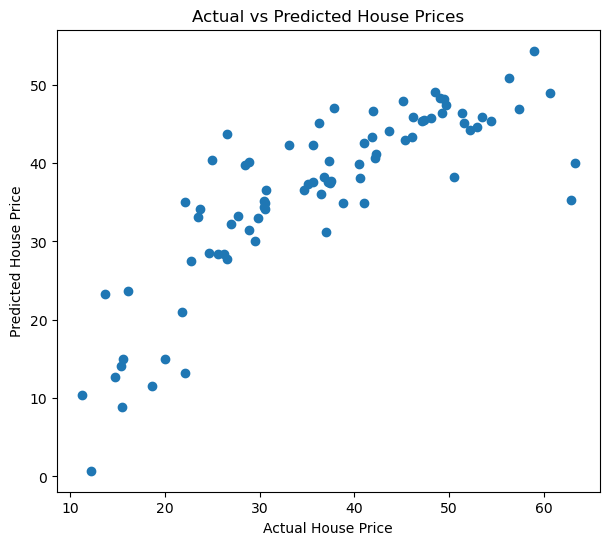

In [85]:
# Create an actual-versus-predicted plot for the multivariate model.

# Creates a new figure for the actual-versus-predicted visualization. The figure is 7 inches wide and 6 inches high.
plt.figure(figsize=(7, 6))

# Creates a scatter plot with actual house prices on the x-axis and predicted house prices on the y-axis. Each point represents one test observation.
plt.scatter(
    y_test,
    y_pred_multi
)


plt.xlabel('Actual House Price')    # Labels the horizontal axis as the actual observed house price.
plt.ylabel('Predicted House Price') # Labels the vertical axis as the price predicted by the regression model.
plt.title('Actual vs Predicted House Prices')  # Adds a descriptive title to the graph.

# Displays the actual-versus-predicted scatter plot.
plt.show()

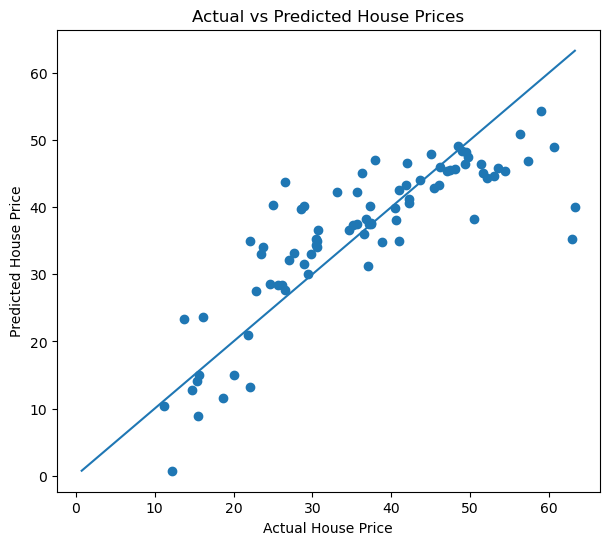

In [86]:
# Interpretation
# Ideally, predictions should lie close to the hypothetical line:
# y_predicted = y_actual

# Add this reference line:
# Finds the smallest value among the actual and predicted prices. This provides the lower endpoint for the reference line.
min_value = min(y_test.min(), y_pred_multi.min())   
# Finds the largest value among the actual and predicted prices. This provides the upper endpoint for the reference line.
max_value = max(y_test.max(), y_pred_multi.max())

# Creates a new figure for the improved actual-versus-predicted plot.
plt.figure(figsize=(7, 6))

# Plots actual house prices against predicted house prices.
plt.scatter(y_test, y_pred_multi)

# Draws the ideal prediction line (y=x). A prediction exactly equal to the actual value would lie on this line.
plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel('Actual House Price')    # Labels the x-axis as the actual observed house price.
plt.ylabel('Predicted House Price') # Labels the y-axis as the model's predicted price.
plt.title('Actual vs Predicted House Prices')  # Adds a descriptive title to the graph.

plt.show()  # Displays the final visualization.

In [ ]:
# Create a NumPy/pandas input:

# Create a DataFrame containing these values.
new_property = pd.DataFrame({                         # Creates a pandas DataFrame representing the new property's characteristics.
    'X1 transaction date': [2013.5],                  # Provides the transaction-date value. The square brackets create a one-row column.
    'X2 house age': [15],                             # Provides the property's house age as 15 years.
    'X3 distance to the nearest MRT station': [500],  # Provides the property's distance from the nearest MRT station as 500 metres.
    'X4 number of convenience stores': [6],           # Provides the number of nearby convenience stores.   
    'X5 latitude': [24.98],                           # Provides the property's latitude.  
    'X6 longitude': [121.54]                          # Provides the property's longitude. 
})


# Predict its price:
# Passes the new property's six predictor values to the trained multivariate regression model. The model returns its estimated house price.
predicted_price = model_multi.predict(new_property)

# Displays the first prediction. Because only one property was supplied, predicted_price[0] extracts its predicted price from the prediction array.
print("Predicted price:", predicted_price[0])